In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
jamission = pd.read_csv("D:\Courses\Scaler\Database\Jamboree_Admission\Jamboree_Admission.csv")

In [3]:
jamission.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
jamission.shape

(500, 9)

In [5]:
jamission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [6]:
jamission.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


# Exploratory Data Analysis 

In [7]:
#removing serial No. feature column as it is not required for prediction model
jamission.drop(columns = 'Serial No.', inplace= True)

In [8]:
jamission.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


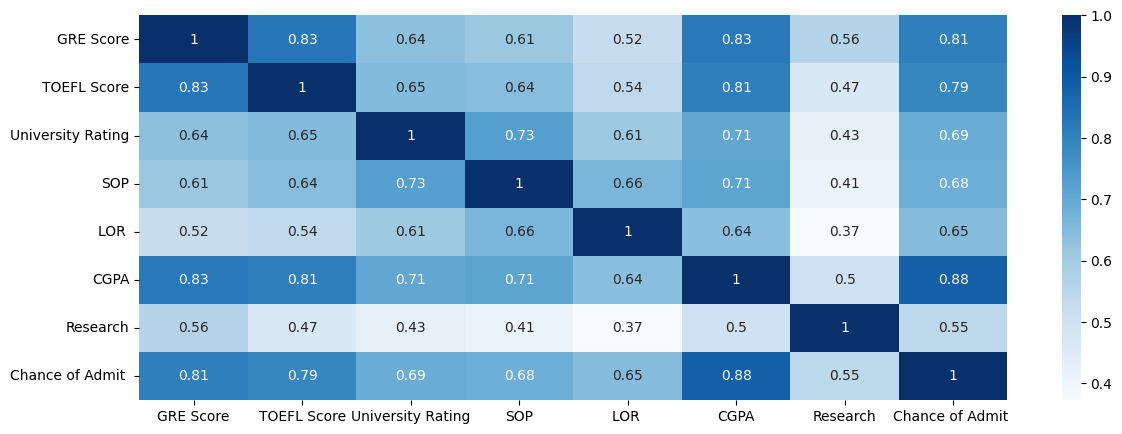

In [9]:
jamb_corr = jamission.corr()
plt.figure(figsize=(14,5))
sns.heatmap(jamb_corr, annot= True, cmap='Blues');

* Chance of Admit is highly correlated with GRE Score, TOFEL Score & CGPA
* There exists a significant correlation between GRE scores and TOEFL scores, indicating that students who excel in the GRE tend to also perform well in the TOEFL.
* There exists a significant correlation between CGPA and both GRE and TOEFL scores, as higher scores tend to enhance a student's CGPA.

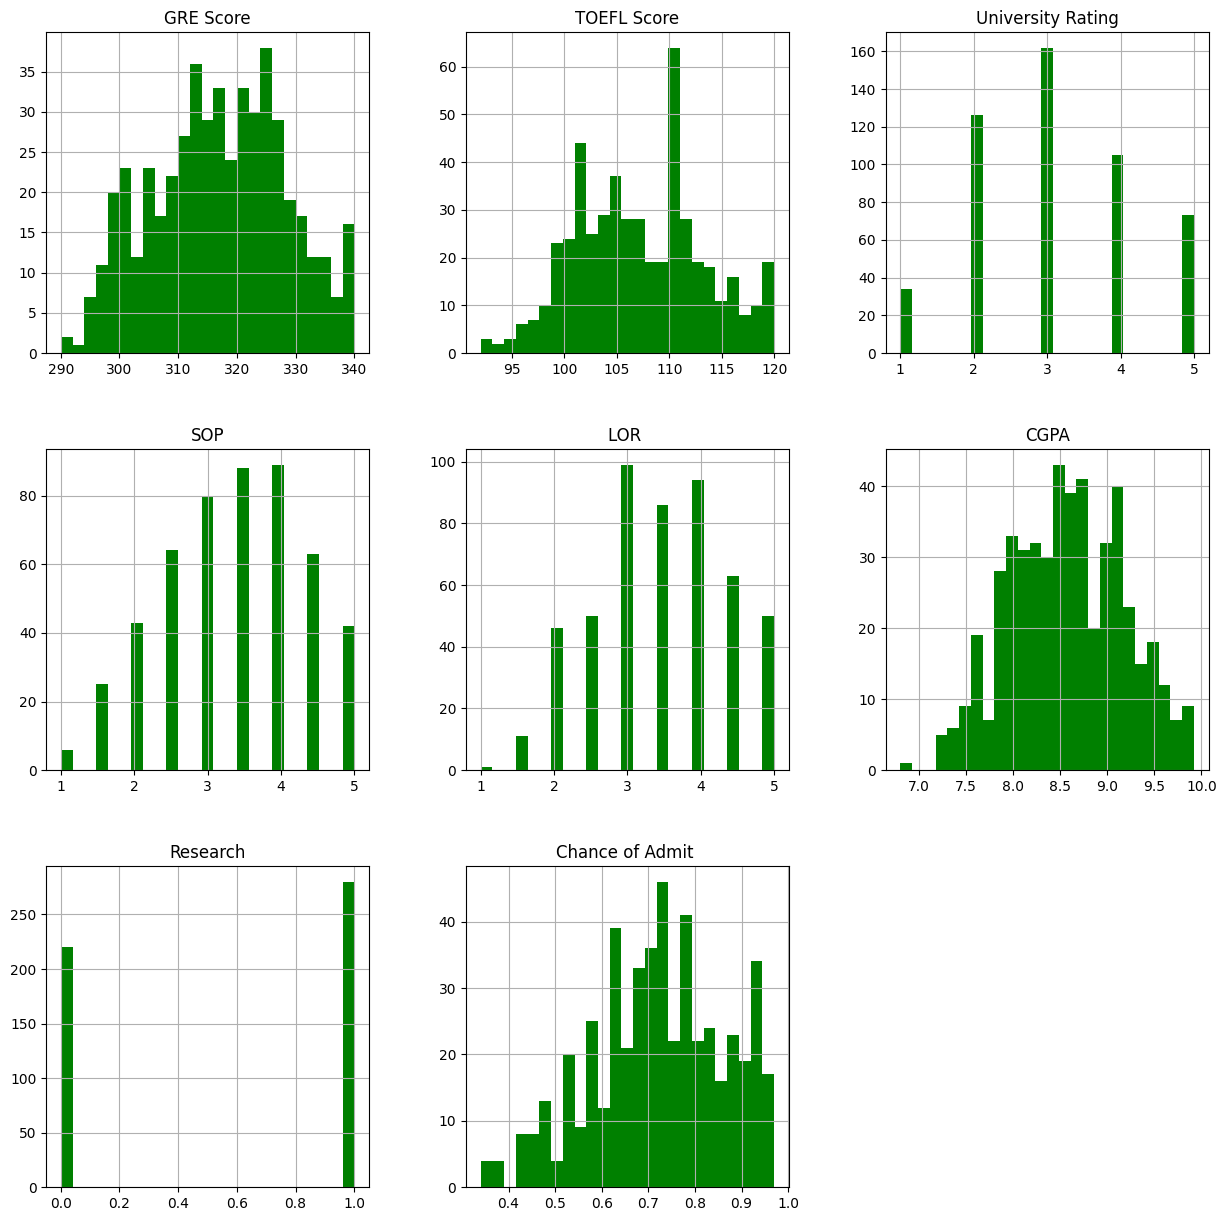

In [10]:
jamission.hist(color = 'green', figsize=(15,15), bins = 25)
plt.show()

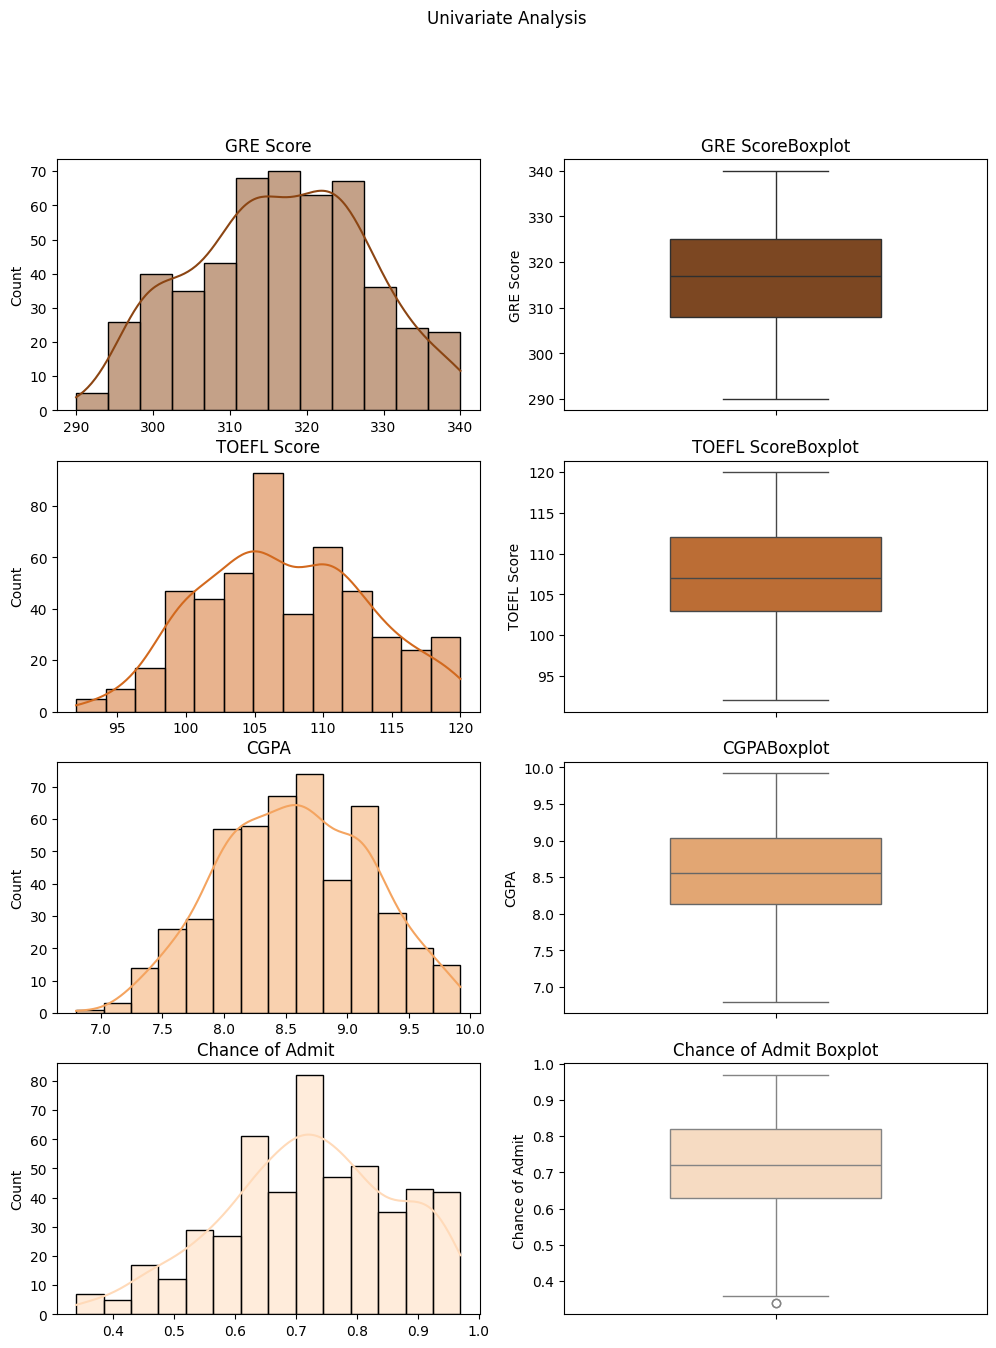

In [11]:
n_cols = ['GRE Score', 'TOEFL Score', 'CGPA', 'Chance of Admit ']
colors = ['saddlebrown', 'chocolate', 'sandybrown', 'peachpuff']
fig, ax = plt.subplots(len(n_cols), 2, figsize=(12, 15))
for i in range(len(n_cols)):
    sns.histplot(jamission[n_cols[i]], ax = ax[i,0], color=colors[i], kde= True)
    ax[i,0].set_title(n_cols[i], fontsize= 12)
    ax[i,0].set_xlabel('')
    sns.boxplot(jamission[n_cols[i]], ax = ax[i,1], width=0.5, color = colors[i])
    ax[i,1].set_title(n_cols[i] + str("Boxplot"))
    ax[i,1].set_xlabel('')
plt.suptitle("Univariate Analysis")
plt.show();

* No outliers can be seen
* GRE Score and TOFEL Score share Gaussin Distribution Characteristics
* CGPA depicts Gaussin Dist While KDE is TRUE 

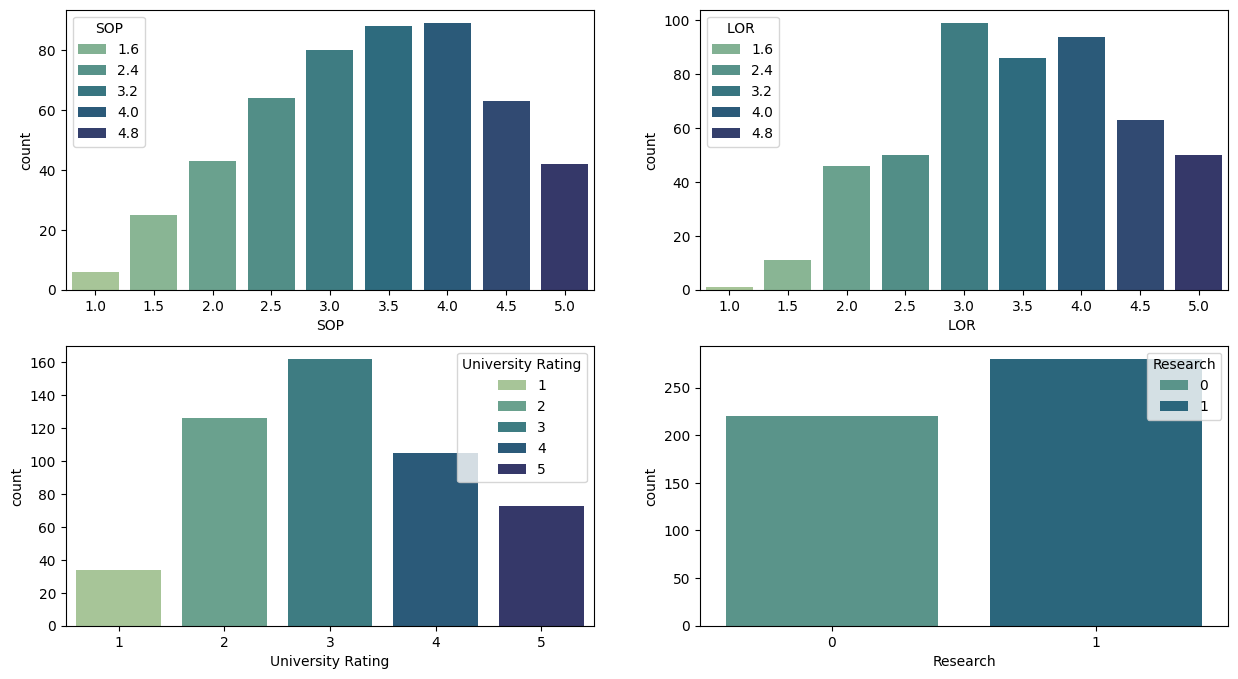

In [12]:
#Count plotting for Sop, Lor, University Rating & Research 

fig = plt.figure(figsize=(15,8))
#plot SOP
ax = fig.add_subplot(2,2,1)
sns.countplot(x = jamission['SOP'], palette = 'crest', hue = jamission['SOP'] )

#Plot LOR
ax = fig.add_subplot(2,2,2)
sns.countplot(x = jamission['LOR '], palette = 'crest', hue = jamission['LOR '])

#plot University Rating
ax = fig.add_subplot(2,2,3)
sns.countplot(x = jamission['University Rating'], palette = 'crest', hue = jamission['University Rating'])

#plot Research 
ax = fig.add_subplot(2,2,4)
sns.countplot(x = jamission['Research'], palette = 'crest', hue = jamission['Research'])

plt.show()



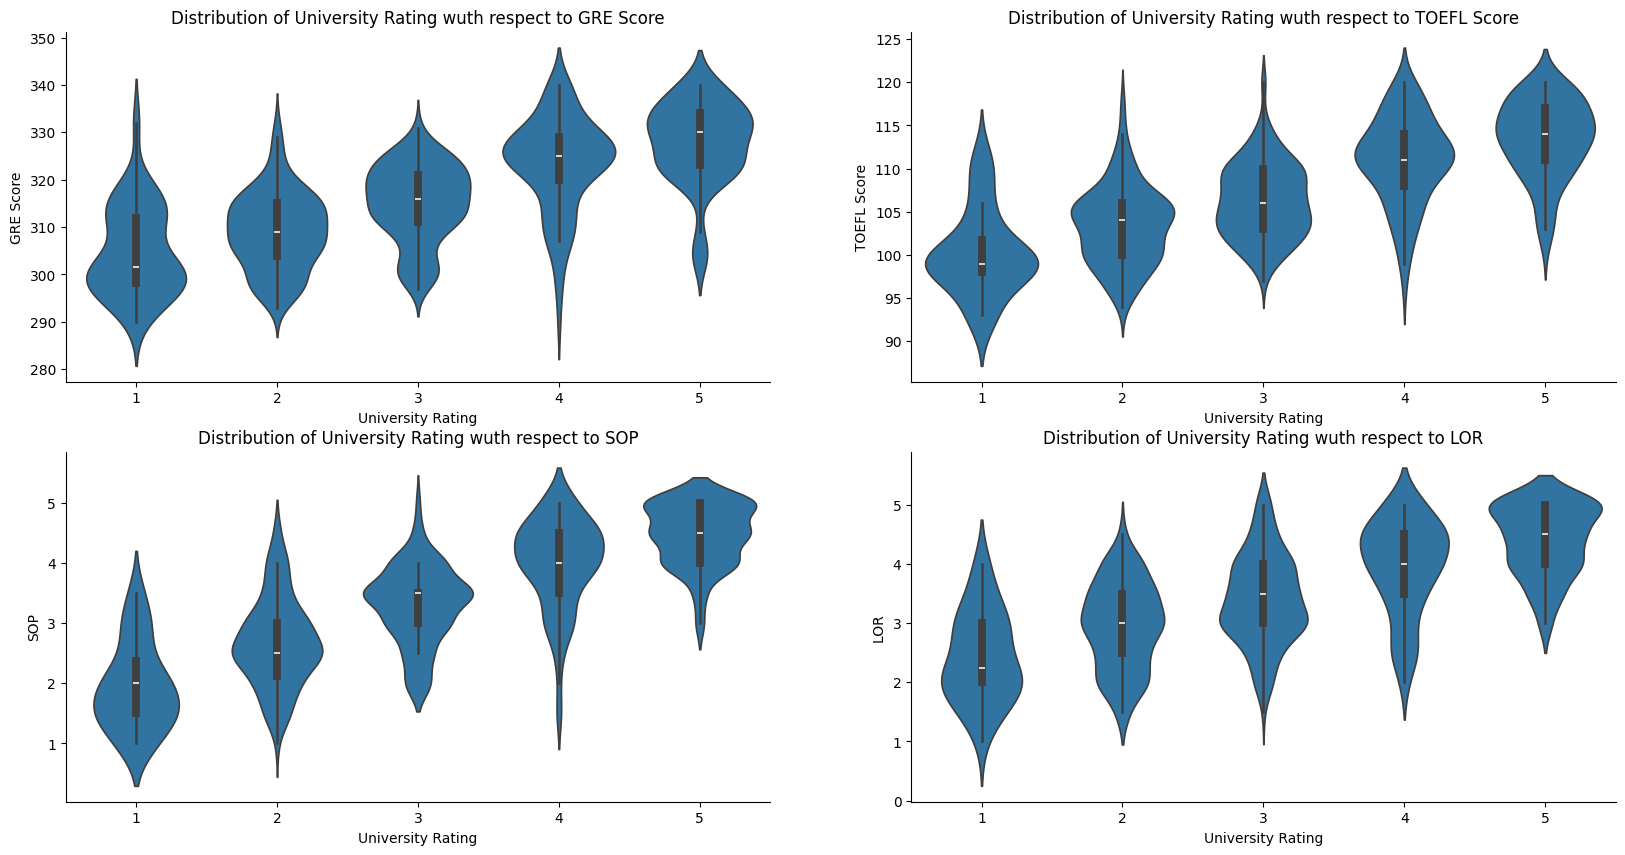

In [13]:
# Distrbution of University Rating in context with [ 'GRE Scores', 'TOEFL Scores', 'SOP', 'LOR']

fig = plt.figure(figsize=(20,10))
# University rating wrt GRE Scores
ax = fig.add_subplot(2,2,1)
sns.violinplot(x=jamission['University Rating'], y = jamission['GRE Score'] )
plt.title('Distribution of University Rating wuth respect to GRE Score')

#University rating wrt TOEFL Score
ax = fig.add_subplot(2,2,2)
sns.violinplot(x=jamission['University Rating'], y = jamission['TOEFL Score'])
plt.title('Distribution of University Rating wuth respect to TOEFL Score')

#University rating wrt SOP
ax = fig.add_subplot(2,2,3)
sns.violinplot(x=jamission['University Rating'], y = jamission['SOP'])
plt.title('Distribution of University Rating wuth respect to SOP')

#University rating wrt LOR
ax = fig.add_subplot(2,2,4)
sns.violinplot(x=jamission['University Rating'], y = jamission['LOR '])
plt.title('Distribution of University Rating wuth respect to LOR')

sns.despine()
plt.show();

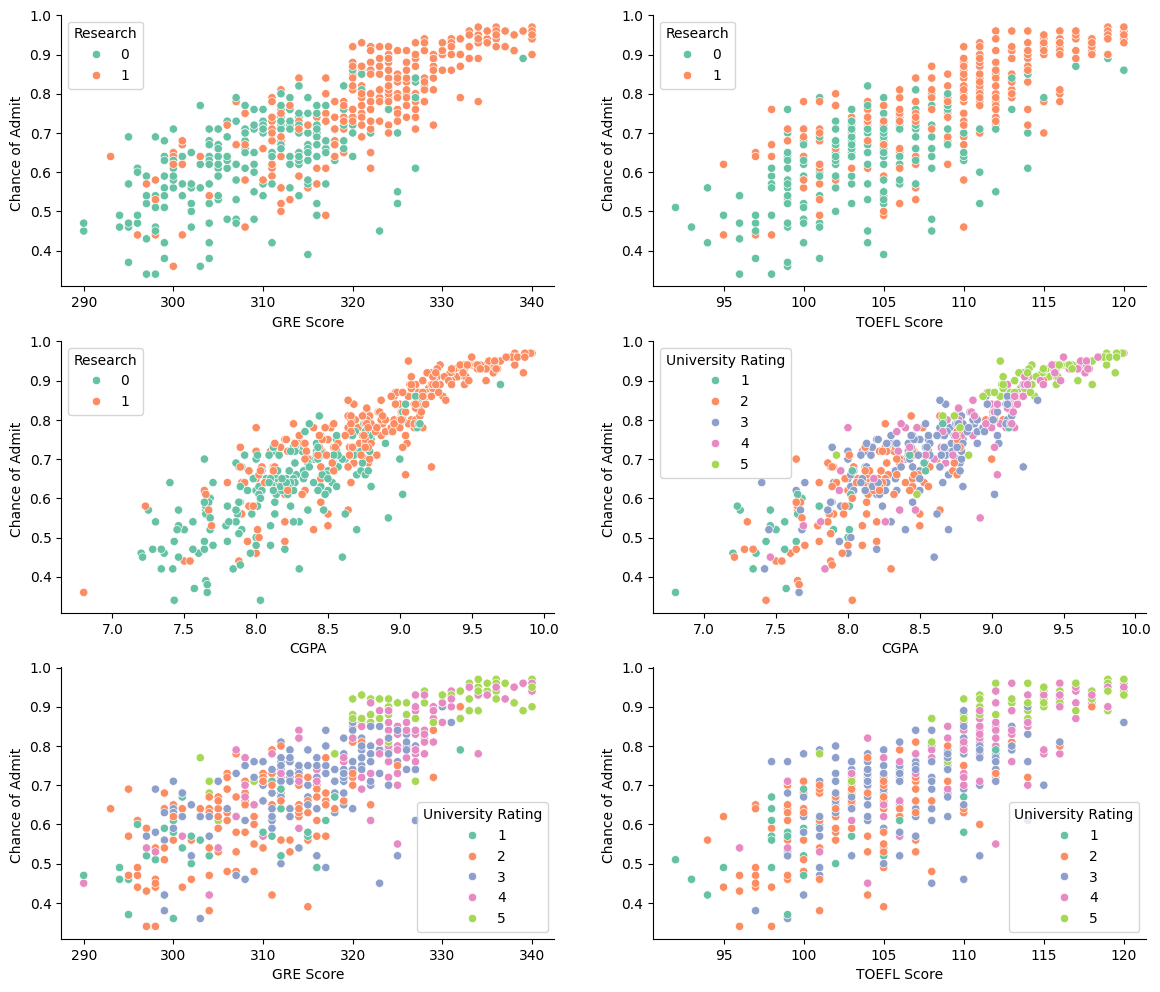

In [14]:
#Scatter Plot of [Chance of Admit] in relation to [GRE, TOEFL, CGPA] based on Research 
fig, ax = plt.subplots(3,2, figsize=(14,12))
sns.scatterplot(data = jamission, x='GRE Score', y='Chance of Admit ',hue='Research', ax=ax[0,0],palette='Set2')
sns.scatterplot(data = jamission, x='TOEFL Score', y='Chance of Admit ',hue='Research', ax=ax[0,1],palette='Set2')
sns.scatterplot(data = jamission, x='CGPA', y='Chance of Admit ',hue='Research', ax=ax[1,0],palette='Set2')

#Scatter Plot of [Chance of Admit] in relation to [GRE, TOEFL, CGPA] based on University Rating
sns.scatterplot(data = jamission, x='CGPA', y='Chance of Admit ',hue='University Rating', ax=ax[1,1],palette='Set2')
sns.scatterplot(data = jamission, x='GRE Score', y='Chance of Admit ',hue='University Rating', ax=ax[2,0],palette='Set2')
sns.scatterplot(data = jamission, x='TOEFL Score', y='Chance of Admit ',hue='University Rating', ax=ax[2,1],palette='Set2')

sns.despine()
plt.show();

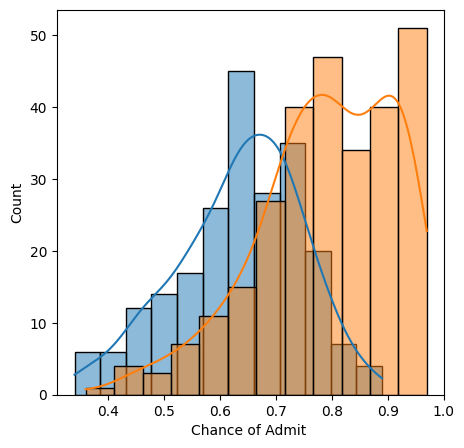

In [15]:
fig=plt.figure(figsize=(5,5))
sns.histplot(jamission[jamission['Research']==0]['Chance of Admit '], label ='0', kde = True)
sns.histplot(jamission[jamission['Research']==1]['Chance of Admit '], label ='1', kde = True)
plt.show()

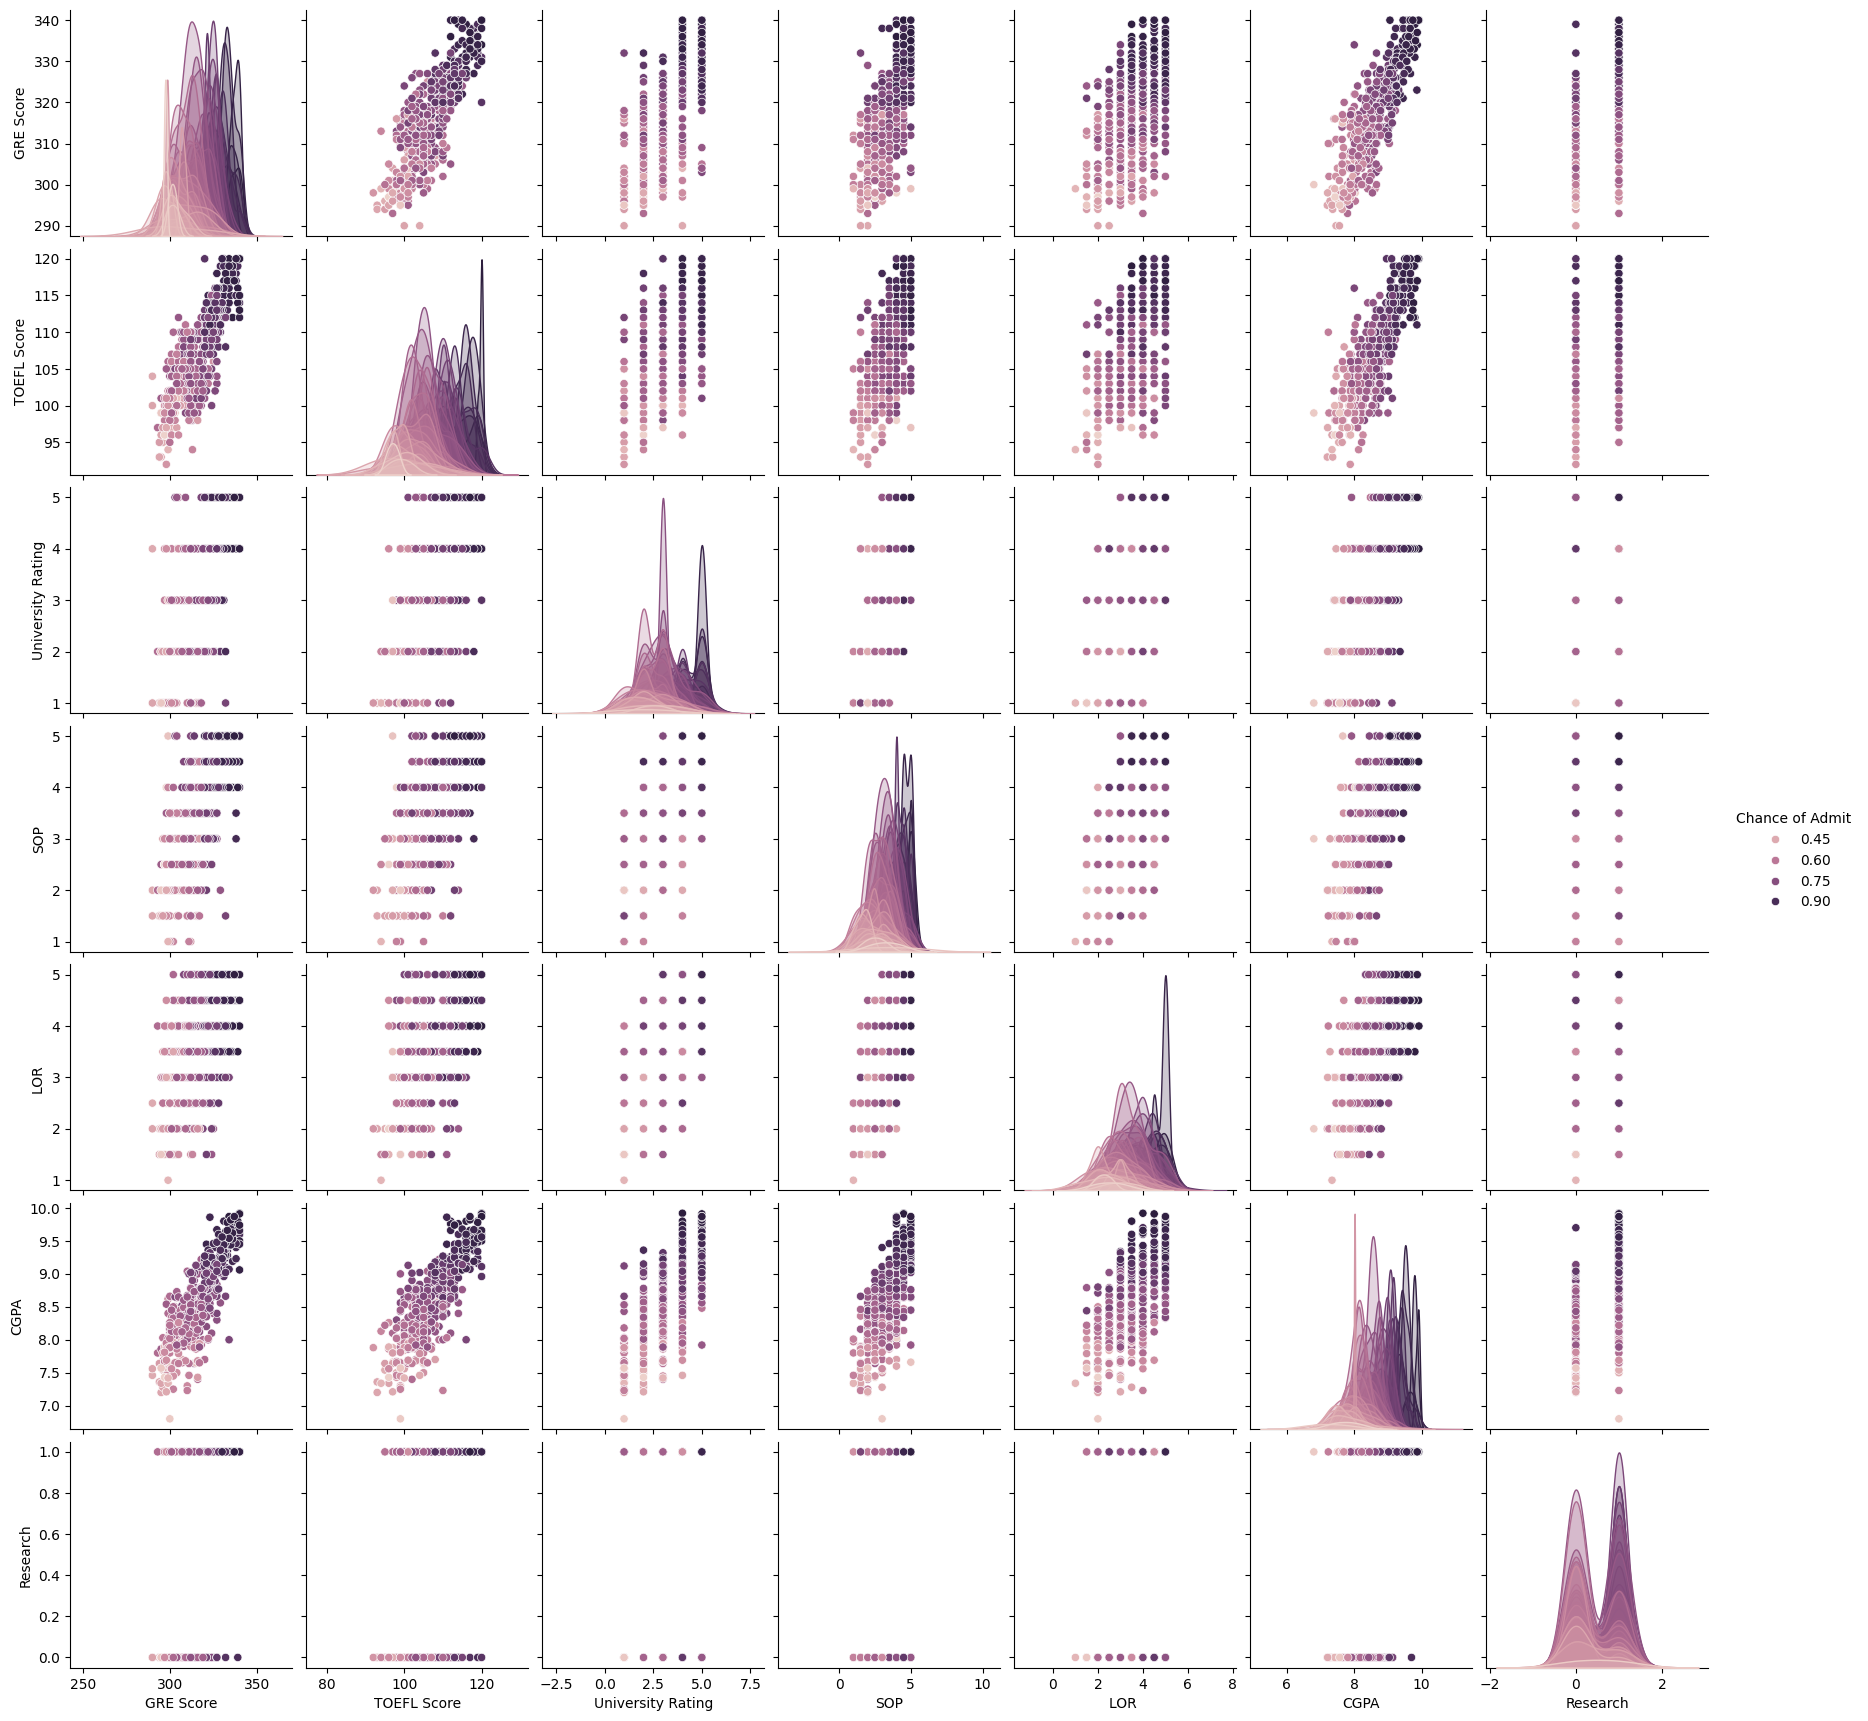

In [16]:
sns.pairplot(data=jamission,hue='Chance of Admit ')
plt.show()

## Observation
* The student who achieved the highest scores in both the GRE and TOEFL received university ratings of 4 and 5, respectively.
* The University Rating of '4' assigned to both GRE and TOEFL scorers exhibits a remarkably similar distribution.
* Maximum marks scored by GRE students received University Rating as '4' and '5'.* 
Maximum number of students doing research received a University Rating of 3
* As University Ratings increases, GRE scores and TOEFL score increses.* The level of LOR rises in conjunction with SOP.
.

### Data Transformation

In [17]:
jamission.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [18]:
# Renaming the column
jamission.rename(columns = {'LOR ':'LOR', 'Chance of Admit ': 'Chance of admit' }, inplace = True)

# Linear Regression

In [19]:
jamission.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


## Linear regression - {y = (w1x1) + (w2x2) .......... (wnxn) + w0}x = dependent variable

y = independent variable / predicted variable


In [20]:
import scipy as sp
from  scipy import stats
import math
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn import preprocessing, svm
from statsmodels.formula.api import ols

In [21]:
x = jamission.drop(columns ='Chance of admit')
y = jamission['Chance of admit']

In [22]:
x_train,x_text, y_train, y_test = train_test_split(x,y,test_size=0.20, random_state = 42)

In [23]:
# applying standardScaler on x
scale = StandardScaler()
scale.fit(x)
x= scale.transform(x)

In [24]:
#LinearREgresion
lin_reg =LinearRegression()
lin_reg.fit(x_train, y_train)

LinearRegression()

In [25]:
print(f'The Coefficient of Linear Regression : {lin_reg.coef_}')

print(f'The intercept of Linear Regression:{lin_reg.intercept_}')

The Coefficient of Linear Regression : [0.00243444 0.00299587 0.0025688  0.00181369 0.01723798 0.11252708
 0.02402679]
The intercept of Linear Regression:-1.4214470719016474


## Checking MAE, Score, RSME, R^2 and Adjusted R^2 for Linear Regression


In [26]:
y_predict = lin_reg.predict(x_text)

In [27]:
print('Score for Training Data:', lin_reg.score(x_train,y_train))
print('-' * 25)
print('Score for Test Data:', lin_reg.score(x_text,y_test))
print('-'*25)
print('Mean absolute error:', mean_absolute_error(y_true=y_test, y_pred=y_predict))
print('-'*25)
print('Root Mean Squared Error', root_mean_squared_error(y_true=y_test, y_pred = y_predict))
print('-'*25)
print('R^2:',r2_score(y_test,y_predict))
print('-'*25)
print('Adjusted R^2:',(1-(1-(r2_score(y_test,y_predict)))*(len(y)-1)/(len(y)-x.shape[1]-1)))

Score for Training Data: 0.8210671369321555
-------------------------
Score for Test Data: 0.8188432567829631
-------------------------
Mean absolute error: 0.04272265427705369
-------------------------
Root Mean Squared Error 0.06086588041578308
-------------------------
R^2: 0.8188432567829631
-------------------------
Adjusted R^2: 0.8162658234445094


### observation: CGPA holds the highest significance in the coefficients among all variables in the context of Linear Regression.

## 1. REGULARIZATION(L2) - RIDGE REGRESSION


Ridge regression performs ‘L2 regularization‘, i.e. it adds a factor of sum of squares of coefficients in the optimization objective. Thus, ridge regression optimizes the following:

Objective = RSS + α * (sum of square of coefficients)


In [29]:
ridge_reg = Ridge(alpha=0)
ridge_reg.fit(x_train, y_train)
ridge_reg.coef_

array([0.00243444, 0.00299587, 0.0025688 , 0.00181369, 0.01723798,
       0.11252708, 0.02402679])

* The Ridge Regression Coefficients aligns with that of simple linear regression. 
* The coefficients will correspond to those found in simple linear regression.

In [30]:
ridge_reg = Ridge(alpha=1)
ridge_reg.fit(x_train,y_train)
ridge_reg.coef_

array([0.00252146, 0.0030726 , 0.00276683, 0.00216403, 0.01747795,
       0.10907905, 0.02367853])

In [31]:
ridge_reg = Ridge(alpha=2)
ridge_reg.fit(x_train, y_train)
ridge_reg.coef_

array([0.00260353, 0.00314479, 0.00295385, 0.00249203, 0.01769704,
       0.1058438 , 0.02334041])

* The value of α, when it lies between 0 and infinity, will determine the significance assigned to various components of the objective.
* In the context of simple linear regression, the coefficients will range from 0 to 1.

In [32]:
ridge_reg = Ridge(alpha=3)
ridge_reg.fit(x_train,y_train)
ridge_reg.coef_

array([0.00268107, 0.00321285, 0.00313079, 0.00279969, 0.01789725,
       0.10280217, 0.02301201])

In [34]:
print('Intercept', ridge_reg.intercept_)

Intercept -1.446214027424984


In [35]:
reg_pred = ridge_reg.predict(x_text)

## Checking MAE, Score, RSME, R^2 and Adjusted R^2 for Ridge Regression


In [37]:
print('Ridge Regression Score for Training data:', ridge_reg.score(x_train,y_train))
print('-'*25)
print('Ridge Regression Score for test data:', ridge_reg.score(x_text,y_test))
print('-'*25)
print('Mean Absolute Error:', mean_absolute_error(y_true=y_test, y_pred=reg_pred))
print('-'*25)
print('Root Mean Squared Error:', root_mean_squared_error(y_true=y_test, y_pred=reg_pred))
print('-'*25)
print('R^2:', r2_score(y_test,reg_pred))
print('-'*25)
print('Adjusted R^2:',(1-(1-(r2_score(y_test,reg_pred)))*(len(y)-1)/(len(y)-x.shape[1]-1)))



Ridge Regression Score for Training data: 0.8206845351279539
-------------------------
Ridge Regression Score for test data: 0.8161651589964275
-------------------------
Mean Absolute Error: 0.043161377970055564
-------------------------
Root Mean Squared Error: 0.0613141296808742
-------------------------
R^2: 0.8161651589964275
-------------------------
Adjusted R^2: 0.8135496226406856


Text(0.5, 1.0, 'contribution of each weighted variables in predicting Chance of Admission {Ridge Regression} ')

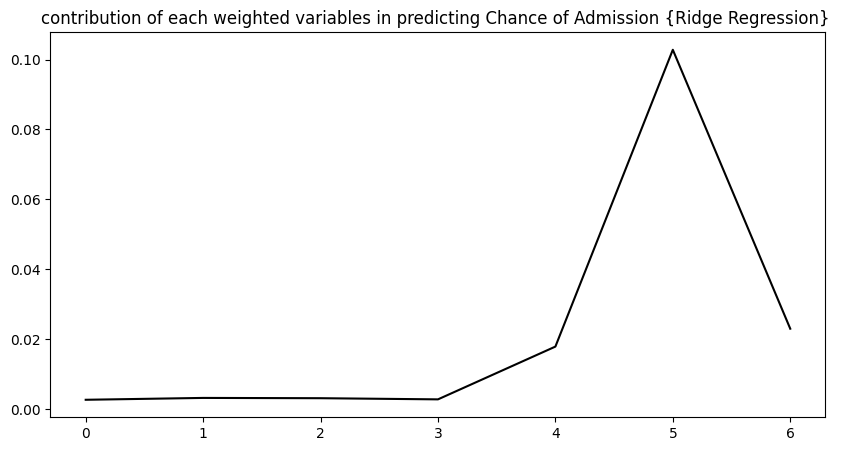

In [39]:
plt.figure(figsize=(10,5))
plt.plot(ridge_reg.coef_, color ='black')
plt.title('contribution of each weighted variables in predicting Chance of Admission {Ridge Regression} ')

The CGPA carries the greatest significance in the coefficients among all variables during the process of Ridge Regularization.

## 2. REGULARIZATION(L1) - LASSO REGRESSION


 Lasso regression implements L1 regularization by incorporating a term that represents the sum of the absolute values of the coefficients into the optimization objective. Consequently, lasso regression seeks to optimize the following:

Objective = RSS + α * (sum of absolute value of coefficients)


In [40]:
laso = Lasso(alpha=0.000001)
laso.fit(x_train,y_train)

Lasso(alpha=1e-06)

In [41]:
print('coefficients:', laso.coef_)

print('Intercept', laso.intercept_)

coefficients: [0.00243487 0.00299614 0.00256902 0.00181369 0.01723792 0.11251769
 0.02402109]
Intercept -1.4215302107399883


In [42]:
laso_pred=laso.predict(x_text)

## Checking MAE, Score, RSME, R^2 and Adjusted R^2 for Lasso Regression


In [44]:
print('Lasso Regression Score of training data:', laso.score(x_train, y_train))
print('-'*25)
print('Lasso Regression Score of Test Data', laso.score(x_text,y_test))
print('-'*25)
print('Mean Absolute Error:', mean_absolute_error(y_true = y_test, y_pred=laso_pred))
print('-'*25)
print('Root mean squared error:', root_mean_squared_error(y_true=y_test, y_pred =laso_pred))
print('-'*25)
print('R^2:', r2_score(y_test,laso_pred))
print('-'*25)
print('Adjusted R^2 score:',(1-(1-(r2_score(y_test,laso_pred)))*(len(y)-1)/(len(y)-x.shape[1]-1)))

Lasso Regression Score of training data: 0.8210671361989014
-------------------------
Lasso Regression Score of Test Data 0.8188389555619382
-------------------------
Mean Absolute Error: 0.042723082913289946
-------------------------
Root mean squared error: 0.06086660298356041
-------------------------
R^2: 0.8188389555619382
-------------------------
Adjusted R^2 score: 0.8162614610272503


Text(0.5, 1.0, 'contribution of each weighted variables in predicting Chance of Admission {Lasso Regression} ')

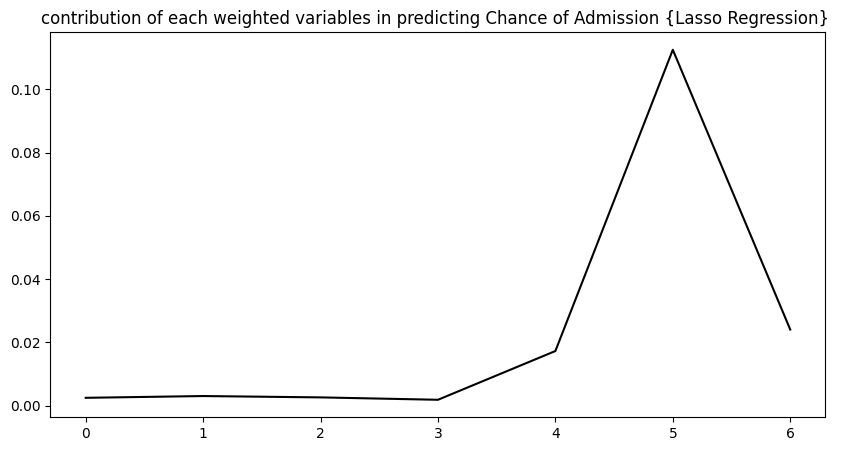

In [45]:
plt.figure(figsize=(10,5))
plt.plot(laso.coef_, color ='black')
plt.title('contribution of each weighted variables in predicting Chance of Admission {Lasso Regression} ')

### Observation
CGPA holds the highest significance in the coefficients among all variables during the Lasso Regression analysis.

## Elastic Net 
Elastic Net serves as a compromise between Ridge Regression and Lasso Regression. The regularization component is a straightforward combination of the regularization terms from both Ridge and Lasso, allowing for the adjustment of the mixing ratio, denoted as r.

When r = 0, Elastic Net is equivalent to Ridge Regression, and when r = 1, it is equivalent to Lasso Regression


In [46]:
n = (0.00001, 0.0001, 0.001, 0.01)
for i in range(len(n)):
    net = ElasticNet(alpha=i)
    net.fit(x_train,y_train)
    print('Coefficients:', net.coef_)
    print('Intercept:', net.intercept_)
    

Coefficients: [0.00243444 0.00299587 0.0025688  0.00181369 0.01723798 0.11252708
 0.02402679]
Intercept: -1.4214470719016434
Coefficients: [0.00632212 0.         0.         0.         0.         0.
 0.        ]
Intercept: -1.2782149921392243
Coefficients: [0.00216457 0.         0.         0.         0.         0.
 0.        ]
Intercept: 0.03859771307360926
Coefficients: [0. 0. 0. 0. 0. 0. 0.]
Intercept: 0.7241749999999999


C:\Users\hardi\anaconda3\Lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\hardi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\hardi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.053e-01, tolerance: 7.884e-04 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinat

#### Taking alpha as 0.00001

In [47]:
net = ElasticNet(alpha=0.00001)
net.fit(x_train,y_train)
print('Coefficients:', net.coef_)
print('Intercept:', net.intercept_)

Coefficients: [0.00243674 0.0029974  0.00257008 0.00181432 0.01723826 0.11247386
 0.02399792]
Intercept: -1.421872794968781


In [48]:
net_pred = net.predict(x_text)

### Checking MAE, Score, RSME, R^2 and Adjusted R^2 for Elastic Net 


In [50]:
print('Elastic Net Score for training data :', net.score(x_train,y_train))
print('-'*25)
print('Elastic Net Score for Test Data:', net.score(x_text,y_test))
print('-'*25)
print('Mean absolute error:', mean_absolute_error(y_true = y_test, y_pred=net_pred))
print('-'*25)
print('Root Mean Squared Error:', root_mean_squared_error(y_true=y_test, y_pred = net_pred))
print('-'*25)
print('R^2:', r2_score(y_test, net_pred))
print('-'*25)
print('Adjusted R^2 Score:', (1-(1-(r2_score(y_test,net_pred)))*(len(y)-1)/(len(y)-x.shape[1]-1)))

Elastic Net Score for training data : 0.8210671158795124
-------------------------
Elastic Net Score for Test Data: 0.8188203217624072
-------------------------
Mean absolute error: 0.04272506585304818
-------------------------
Root Mean Squared Error: 0.060869733200982365
-------------------------
R^2: 0.8188203217624072
-------------------------
Adjusted R^2 Score: 0.8162425621126853


## LINEAR REGRESSION ASSUMPTIONS TESTING


1) Multicollinearity check by VIF score (variables are dropped one-by-one till none has VIF>5)

2) The mean of residuals is nearly zero

3) Linearity of variables (no pattern in the residual plot)

4) Test for Homoscedasticity

5) Normality of residuals (almost bell-shaped curve in residuals distribution, points in QQ plot are almost all on the line

### 1) Multicollinearity check by VIF score (variables are dropped one-by-one till none has VIF>5)

In [51]:
x

array([[ 1.81923762,  1.77886545,  0.77558214, ...,  1.09894429,
         1.77680627,  0.88640526],
       [ 0.66714832, -0.03160087,  0.77558214, ...,  1.09894429,
         0.48585943,  0.88640526],
       [-0.0418297 , -0.52536441, -0.09979274, ...,  0.01730621,
        -0.95404281,  0.88640526],
       ...,
       [ 1.19888185,  2.10804114,  1.65095702, ...,  1.63976333,
         1.62785086,  0.88640526],
       [-0.39631872, -0.68995225,  0.77558214, ...,  1.63976333,
        -0.24236699, -1.12815215],
       [ 0.93301508,  0.95592621,  0.77558214, ...,  1.09894429,
         0.76721964, -1.12815215]])

In [52]:
jamission.head(2)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76


In [54]:
col = jamission[['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research']]
x1= np.array(x_train)
vif =[]
for i in range(x1.shape[1]):
    vif.append(round(variance_inflation_factor(x1, i),2))
vif_score = pd.DataFrame({'columns':['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research'], 'VIF Score':vif})

In [55]:
vif_score

,columns,VIF Score
0,GRE Score,1284.07
1,TOEFL Score,1141.17
2,University Rating,20.41
3,SOP,34.84
4,LOR,30.25
5,CGPA,933.06
6,Research,2.82


We see that almost all the variables (excluding research) have a very high level of colinearity. This was also observed from the correlation heatmap which showed strong positive correlation between GRE score, TOEFL score and CGPA.

### 2) The mean of residuals is nearly zero

In [56]:
normal = y_test -y_predict
print('Mean of Residual', (sum(np.array(normal)/len(normal))))

Mean of Residual -0.005453623717660822


Since the mean of residuals is very close to 0, we can say that the model is unbiased

### 3) Linearity of variables (no pattern in the residual plot

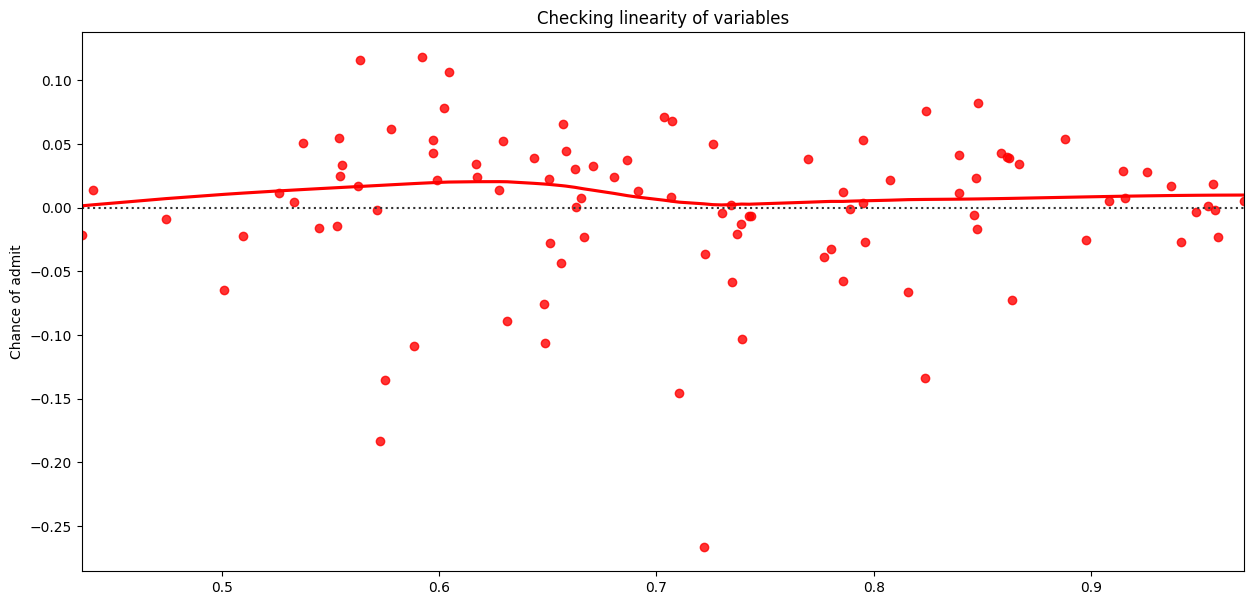

In [57]:
plt.figure(figsize=(15,7))
sns.residplot(x=y_predict, y=normal, lowess = True, color ='red')
plt.title('Checking linearity of variables')
plt.show()

No linearity of Variable can be observed

### 4) Test for Homoscedasticity

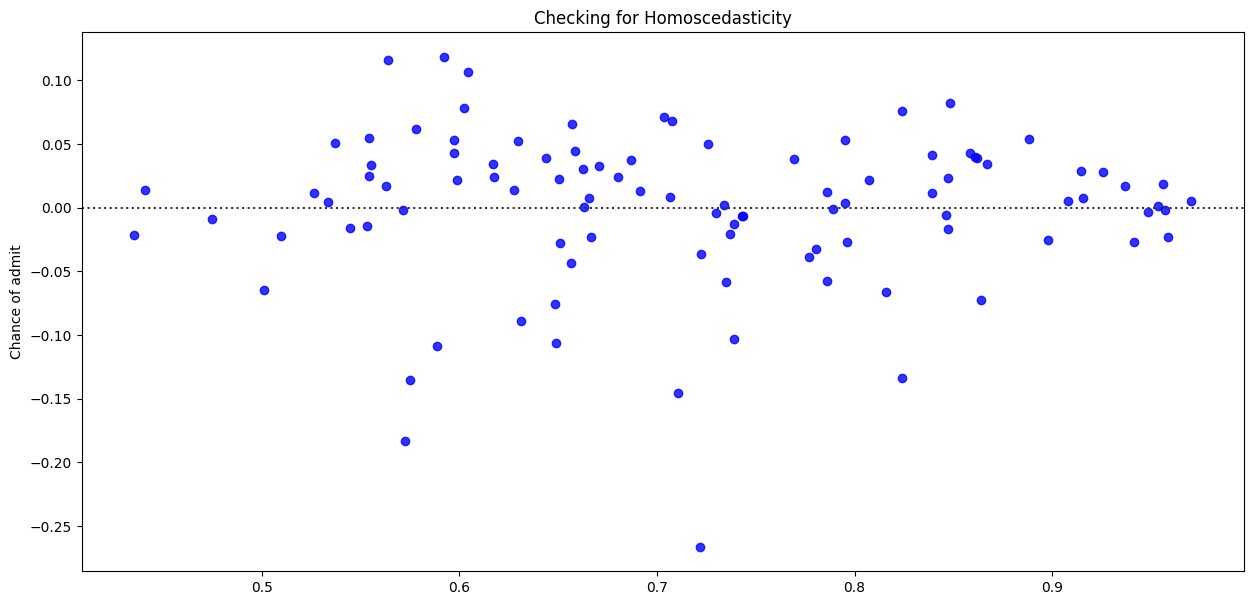

In [58]:
plt.figure(figsize=(15,7))
sns.residplot(x=y_predict, y=normal, color='blue')
plt.title('Checking for Homoscedasticity')
plt.show();

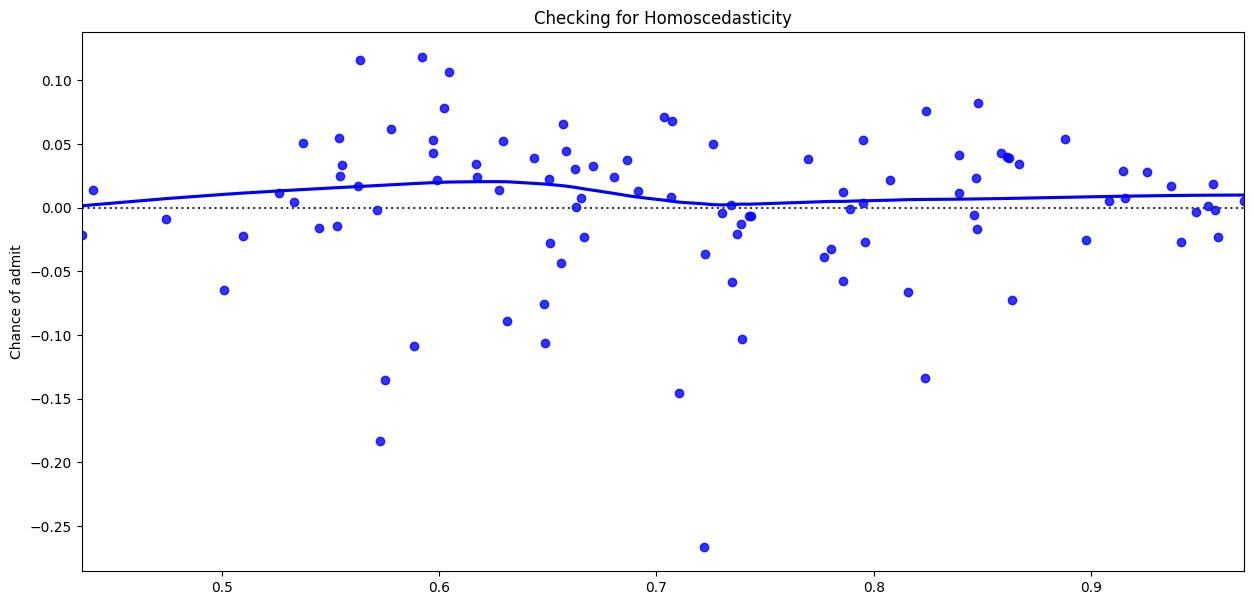

In [59]:
plt.figure(figsize=(15,7))
sns.residplot(x=y_predict, y=normal, lowess=True, color='blue')
plt.title('Checking for Homoscedasticity')
plt.show();

### 5) Normality of residuals (almost bell-shaped curve in residuals distribution, points in QQ plot are almost all on the line)

In [61]:
normal = y_test - y_predict
normal.head()

361    0.015425
73     0.044819
374   -0.182660
155    0.062630
104   -0.075883
Name: Chance of admit, dtype: float64

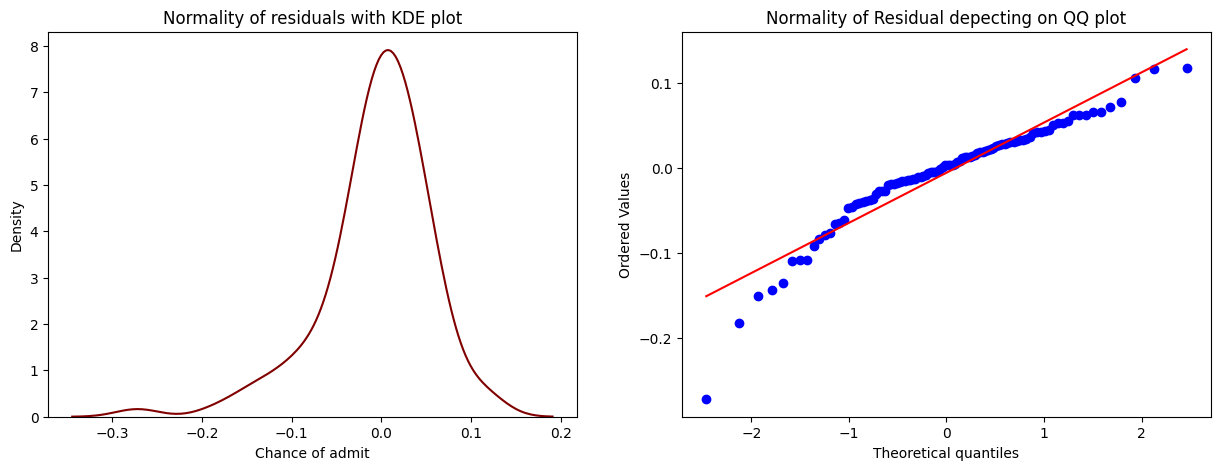

In [62]:
#qq - plot and kde plot of residuals

fig = plt.figure(figsize=(15,5))
ax = fig.add_subplot(1,2,1)
sns.kdeplot(x=normal, color = 'maroon')
plt.title('Normality of residuals with KDE plot')

ax = fig.add_subplot(1,2,2)
sp.stats.probplot(normal, plot=plt)
plt.title('Normality of Residual depecting on QQ plot')
plt.show()

# Observations


The distribution of the target variable, which represents the likelihood of admission, exhibits a left-skewed pattern. There exists a strong positive correlation between exam scores (CGPA, GRE, TOEFL) and the probability of admission, with these variables also demonstrating high inter-correlation. Categorical variables, including university ranking, research experience, and the quality of the Statement of Purpose (SOP) and Letters of Recommendation (LOR), indicate a positive trend in the chances of admission.

Analysis of the model coefficients reveals that CGPA serves as the most significant predictor, whereas the SOP and university rating are the least impactful. Both the Linear Regression and Ridge Regression models, identified as the most effective, account for approximately 82% of the variance in the target variable (likelihood of admission). The presence of high multicollinearity among the predictor variables complicates efforts to enhance model performance.

Aside from multicollinearity, the predictor variables satisfy the necessary conditions for Linear Regression, including a mean of residuals close to zero, linear relationships among variables, normal distribution of residuals, and established homoscedasticity.

# Suggestions:

Given the strong correlation among all exam scores, it is advisable to incorporate additional independent features to enhance predictive accuracy. Potential independent variables may include work experience, internships, performance in mock interviews, participation in extracurricular activities, or diversity-related factors.